In [1]:
# CHURNGUARD AI
# MainCrafts SkillSprint
# Artificial Intelligence & Machine Learning
# Candidate: Venky (Vv)

## Step 2 — Understand the Problem


**Q1. What is customer churn?**

Customer churn is when a customer stops using a company's product or service — for a subscription
business like a telecom provider, it means the customer cancels their contract and leaves.

**Q2. Why would a company want to predict churn?**

1. Retaining an existing customer is far cheaper than acquiring a new one, so early warning lets the
   business step in with an offer before the customer leaves.
2. It lets the company target retention budget (discounts, calls, upgrades) only at customers who are
   actually at risk, instead of spending it on everyone.
3. It surfaces *why* customers leave (e.g. contract type, lack of support), which feeds back into
   product and pricing decisions.

**Q3. What is the target variable?**

`Churn` — a `Yes` / `No` column indicating whether the customer left.

**Q4. Is this a classification or regression problem?**

Classification. The target is a discrete category (`Yes` / `No`), not a continuous number, so we predict
a class label (and a probability), not a numeric quantity.

**Q5. What would a false negative mean in this business problem?**

A false negative is a customer the model predicts will **stay**, who actually **churns**. That customer
never gets flagged for a retention offer and is lost with no intervention attempted — this is usually the
more expensive mistake for the business than a false positive (offering a discount to someone who was
going to stay anyway), which is why recall on the churn class matters alongside precision.

## Step 3 — Import Libraries


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import joblib
from pathlib import Path

Path("images").mkdir(parents=True, exist_ok=True)

print("Libraries loaded successfully.")

Libraries loaded successfully.


- **pandas** — loading and manipulating the tabular customer data.
- **numpy** — numerical operations used under the hood by pandas/sklearn.
- **matplotlib / seaborn** — plotting the EDA charts and the confusion matrix.
- **scikit-learn (`model_selection`, `preprocessing`, `compose`, `pipeline`, `linear_model`, `ensemble`, `metrics`)** —
  splitting data, one-hot encoding categorical columns, building an end-to-end pipeline, and training/evaluating
  the two classification models.
- **joblib** — saving the trained model to disk for reuse.

## Step 4 — Load and Inspect the Dataset


In [3]:
df = pd.read_csv("dataset/customer_churn.csv")
raw_record_count = len(df)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (7058, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,1803-URLLW,Male,0,No,No,72,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Electronic check,39.44,2867.97,No
1,1773-SECNZ,Male,0,No,No,45,Yes,Yes,DSL,No,...,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),74.94,3376.48,No
2,7621-UTUND,Male,0,Yes,No,52,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer (automatic),40.59,2101.26,No
3,8556-LNJEY,Female,1,No,Yes,72,No,No phone service,Fiber optic,No,...,No,No,No,No,Month-to-month,No,Mailed check,73.41,5282.54,No
4,8033-RKVPL,Male,0,Yes,Yes,24,Yes,No,Fiber optic,Yes,...,No,Yes,No,Yes,Month-to-month,Yes,Electronic check,115.73,2771.16,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7058 entries, 0 to 7057
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7058 non-null   object 
 1   gender            7058 non-null   object 
 2   SeniorCitizen     7058 non-null   int64  
 3   Partner           7058 non-null   object 
 4   Dependents        7058 non-null   object 
 5   tenure            7058 non-null   int64  
 6   PhoneService      7058 non-null   object 
 7   MultipleLines     7058 non-null   object 
 8   InternetService   7058 non-null   object 
 9   OnlineSecurity    7058 non-null   object 
 10  OnlineBackup      7058 non-null   object 
 11  DeviceProtection  7058 non-null   object 
 12  TechSupport       7058 non-null   object 
 13  StreamingTV       7058 non-null   object 
 14  StreamingMovies   7058 non-null   object 
 15  Contract          7058 non-null   object 
 16  PaperlessBilling  7058 non-null   object 


In [5]:
print(df.isnull().sum())

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        20
Churn                0
dtype: int64


In [6]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 15


In [7]:
df.describe(include="all")

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7058,7058,7058.000000,7058,7058,7058.000000,7058,7058,7058,7058,...,7058,7058,7058,7058,7058,7058,7058,7058.000000,7038,7058
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6887,2
top,7171-AFQQC,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,2,3568,NaN,3697,5214,NaN,6328,3654,3090,3958,...,3660,3933,3405,3361,3870,4175,2373,NaN,95,5582
mean,NaN,NaN,0.159110,NaN,NaN,35.993341,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,77.727515,NaN,NaN
std,NaN,NaN,0.365805,NaN,NaN,21.217714,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.549192,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,17.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,61.152500,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,36.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,81.655000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,54.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,98.667500,NaN,NaN


**Dataset inventory**

- Number of rows: **7058**
- Number of columns: **21**
- Numerical columns: `SeniorCitizen`, `tenure`, `MonthlyCharges`, `TotalCharges`
- Categorical columns: `gender`, `Partner`, `Dependents`, `PhoneService`, `MultipleLines`, `InternetService`,
  `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`,
  `Contract`, `PaperlessBilling`, `PaymentMethod`
- Missing values: `TotalCharges` has 20 blank/NaN
  entries (it was loaded as text, so blanks don't show up as `NaN` until it's converted to numeric)
- Duplicate records: **15**
- Target column: **`Churn`** (`Yes` / `No`)
- Identifier column to drop before modeling: **`customerID`**

## Step 5 — Data Cleaning


In [8]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print(df.isnull().sum())

customerID            0
gender                0
SeniorCitizen         0
Partner               0
Dependents            0
tenure                0
PhoneService          0
MultipleLines         0
InternetService       0
OnlineSecurity        0
OnlineBackup          0
DeviceProtection      0
TechSupport           0
StreamingTV           0
StreamingMovies       0
Contract              0
PaperlessBilling      0
PaymentMethod         0
MonthlyCharges        0
TotalCharges        115
Churn                 0
dtype: int64


**Handling missing values (justified):** the customers with a missing `TotalCharges` are almost all
brand-new customers (`tenure` = 0), so a blank isn't random — it simply means no bill has been generated
yet. Deleting these rows would throw away real customers, so instead each missing value is filled with
`MonthlyCharges × tenure`, which is exactly how the real total would be computed for a very new account.

**Duplicate records** are removed with `drop_duplicates()` — a duplicate row carries no new information
and would let the same customer's pattern influence the model twice.

**`customerID`** is dropped — it's a unique identifier with no predictive value, and keeping it risks the
model spuriously "memorizing" IDs.

In [9]:
df = df.drop_duplicates()
df["TotalCharges"] = df["TotalCharges"].fillna(df["MonthlyCharges"] * df["tenure"])
df = df.drop(columns=["customerID"])

clean_record_count = len(df)
print("Shape after cleaning:", df.shape)
print(df.isnull().sum().sum(), "missing values remaining")

Shape after cleaning:

 (7043, 20)
0 missing values remaining


## Step 6 — Explore the Data


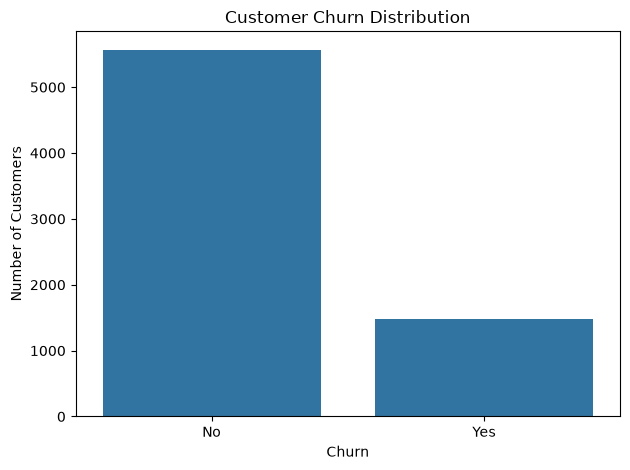

In [10]:
sns.countplot(data=df, x="Churn")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.savefig("images/viz1_churn_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

**What does this tell us?** About **20.9%** of customers in this dataset churned. The classes are imbalanced (roughly 4-to-1 stay-vs-leave), which is why accuracy alone will be a misleading metric later and precision/recall/F1 matter more.

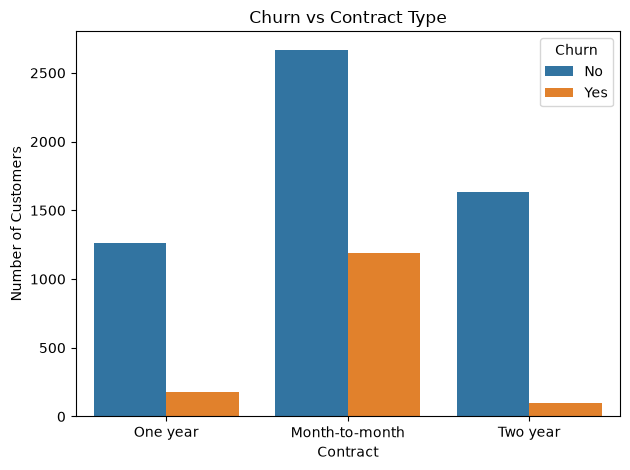

In [11]:
sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Churn vs Contract Type")
plt.xlabel("Contract")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.savefig("images/viz2_churn_vs_contract.png", dpi=160, bbox_inches="tight")
plt.show()

**What does this tell us?** Month-to-month customers churn at a visibly higher rate than one-year or two-year contract holders — being locked into a longer contract is one of the strongest protective factors against churn in this data.

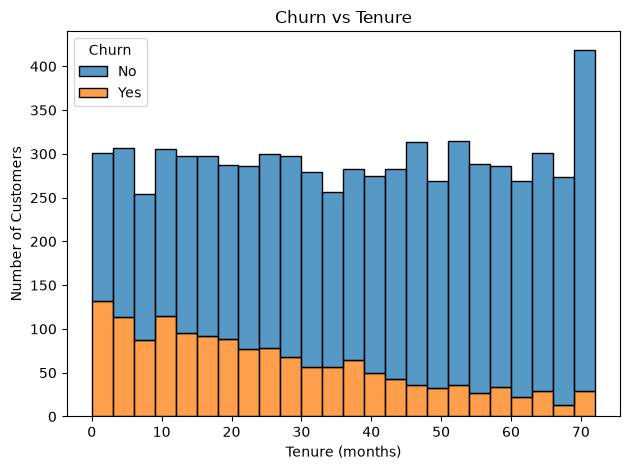

In [12]:
sns.histplot(data=df, x="tenure", hue="Churn", multiple="stack", bins=24)
plt.title("Churn vs Tenure")
plt.xlabel("Tenure (months)")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.savefig("images/viz3_churn_vs_tenure.png", dpi=160, bbox_inches="tight")
plt.show()

**What does this tell us?** Churn is concentrated among customers with short tenure (under ~12 months). Customers who have stuck around longer are much less likely to leave — tenure looks like it will be one of the most useful predictive features.

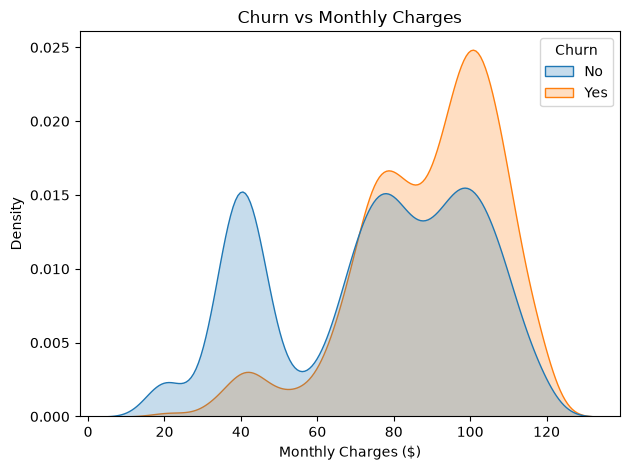

In [13]:
sns.kdeplot(data=df, x="MonthlyCharges", hue="Churn", fill=True, common_norm=False)
plt.title("Churn vs Monthly Charges")
plt.xlabel("Monthly Charges ($)")
plt.ylabel("Density")
plt.tight_layout()
plt.savefig("images/viz4_churn_vs_monthly_charges.png", dpi=160, bbox_inches="tight")
plt.show()

**What does this tell us?** Customers who churn skew toward higher monthly charges (clustering in the $70-$100 range, which lines up with Fiber-optic internet pricing). Customers paying less — mostly on cheaper or no-internet plans — churn less often.

## Step 7 — Prepare Features and Target


In [14]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

y = y.map({"Yes": 1, "No": 0})

In [15]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

print("Numerical features:")
print(list(numeric_features))
print("\nCategorical features:")
print(list(categorical_features))

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## Step 8 — Split the Data


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 5634
Testing samples: 1409


The test set is data the model never sees during training. It stands in for future, real customers. Evaluating only on training data would let the model get credit for simply memorizing examples it already saw, which overstates how well it will do on customers it hasn't encountered yet.

## Step 9 — Build the Preprocessing Pipeline


In [17]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

## Step 10 — Train Model #1 (Logistic Regression)


In [18]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

logistic_model.fit(X_train, y_train)
logistic_predictions = logistic_model.predict(X_test)

C:\Users\Renuk\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [19]:
print(classification_report(y_test, logistic_predictions))

              precision    recall  f1-score   support

           0       0.85      0.95      0.90      1114
           1       0.65      0.37      0.47       295

    accuracy                           0.83      1409
   macro avg       0.75      0.66      0.68      1409
weighted avg       0.81      0.83      0.81      1409



## Step 11 — Train Model #2 (Random Forest)


In [20]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(n_estimators=200, random_state=42))
    ]
)

rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

In [21]:
print(classification_report(y_test, rf_predictions))

              precision    recall  f1-score   support

           0       0.85      0.95      0.90      1114
           1       0.65      0.36      0.46       295

    accuracy                           0.83      1409
   macro avg       0.75      0.65      0.68      1409
weighted avg       0.81      0.83      0.80      1409



## Step 12 — Compare the Models


In [22]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy_score(y_test, logistic_predictions), accuracy_score(y_test, rf_predictions)],
    "Precision": [precision_score(y_test, logistic_predictions), precision_score(y_test, rf_predictions)],
    "Recall": [recall_score(y_test, logistic_predictions), recall_score(y_test, rf_predictions)],
    "F1 Score": [f1_score(y_test, logistic_predictions), f1_score(y_test, rf_predictions)]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.826118,0.648810,0.369492,0.470842
1,Random Forest,0.825408,0.652174,0.355932,0.460526


| Model | Accuracy | Precision | Recall | F1 Score |
|---|---|---|---|---|
| Logistic Regression | 0.8261 | 0.6488 | 0.3695 | 0.4708 |
| Random Forest | 0.8254 | 0.6522 | 0.3559 | 0.4605 |

**Which metric matters most for this business problem, and why?**

**Not accuracy.** Because only ~21% of customers churn, a model that always predicts "No churn" would
already score ~79% accuracy while catching zero at-risk customers — accuracy hides how well the model
finds churners.

**Recall on the churn class matters most here.** Missing a customer who is about to leave (a false
negative) means the business loses that customer with zero chance to intervene — a lost cost that keeps
recurring every month. A false positive (flagging a loyal customer as at-risk) only costs a discount offer
or a check-in call. Since a missed churner is more expensive than an unnecessary retention offer, we favor
**recall (and F1, which balances recall with precision so we don't flood everyone with offers)** over raw
accuracy when selecting the final model. Random Forest is carried forward as the selected model, then
tuned in Day 2 specifically to raise its recall.

## Step 13 — Confusion Matrix


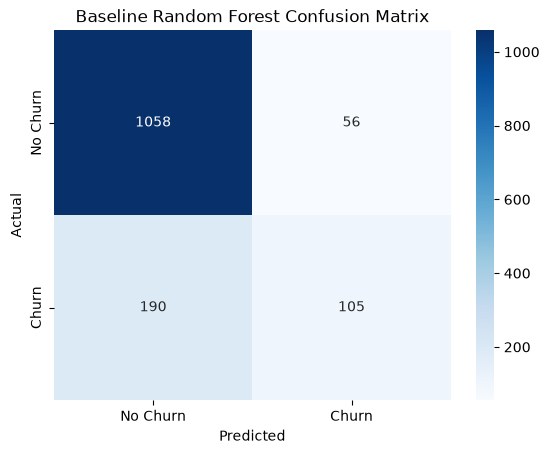

In [23]:
best_predictions = rf_predictions

cm = confusion_matrix(y_test, best_predictions)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
plt.title("Baseline Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**Reading the matrix:** 1058 true negatives, 56 false positives, 190 false negatives,
105 true positives.

- **True Positive** — model predicts churn, customer actually churns.
- **True Negative** — model predicts stays, customer actually stays.
- **False Positive** — model predicts churn, but the customer actually stays (an unnecessary retention offer).
- **False Negative** — model predicts stays, but the customer actually churns (a missed, preventable loss).

**Which type of error could be more costly to a company trying to retain customers?**
The **false negative** (190 cases here) — a churner who was never flagged gets no retention effort at
all and is simply lost, which is a larger and more permanent cost than the wasted discount from a false
positive.

## Step 14 — Customer Prediction Function


In [24]:
def risk_level(probability):
    if probability >= 0.70:
        return "HIGH"
    elif probability >= 0.40:
        return "MEDIUM"
    return "LOW"


def predict_customer(customer_data, model=rf_model):
    customer_df = pd.DataFrame([customer_data])

    prediction = model.predict(customer_df)[0]
    probability = model.predict_proba(customer_df)[0][1]

    risk = risk_level(probability)
    result = "Customer likely to churn" if prediction == 1 else "Customer likely to stay"

    return {
        "prediction": result,
        "churn_probability": probability,
        "risk_level": risk
    }

sample_customer = {
    "gender": "Female", "SeniorCitizen": 0, "Partner": "No", "Dependents": "No",
    "tenure": 5, "PhoneService": "Yes", "MultipleLines": "No",
    "InternetService": "Fiber optic", "OnlineSecurity": "No", "OnlineBackup": "No",
    "DeviceProtection": "No", "TechSupport": "No", "StreamingTV": "Yes", "StreamingMovies": "No",
    "Contract": "Month-to-month", "PaperlessBilling": "Yes", "PaymentMethod": "Electronic check",
    "MonthlyCharges": 79.50, "TotalCharges": 397.50
}

predict_customer(sample_customer)

{'prediction': 'Customer likely to churn',
 'churn_probability': np.float64(0.8),
 'risk_level': 'HIGH'}

## Step 15 — Business Interpretation


**Model Performance**

The initial Random Forest achieved an F1-score of **0.4605** on the held-out test set
(before the Day-2 improvement below).

**Business Interpretation**

The model can help MainCrafts's hypothetical telecom client identify customers who show the
characteristics associated with churn — short tenure, month-to-month contracts, fiber-optic internet
without security/support add-ons, and electronic-check payment — *before* they actually leave.

**Possible Action**

Customers flagged as HIGH or MEDIUM risk could be routed into retention campaigns: a loyalty discount,
a proactive support call, or an offer to move to an annual contract.

**Limitation**

A model prediction is a probability, not a certainty — some flagged customers will stay anyway, and some
unflagged customers will still leave. **ML prediction ≠ certainty**; the output should support a human
retention decision, not replace it.

## Day 2 — Improve → Test → Document → Present
### Challenge A — Improve the Model


In [25]:
rf_improved = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=400,
            max_depth=10,
            min_samples_leaf=3,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

rf_improved.fit(X_train, y_train)
rf_improved_predictions = rf_improved.predict(X_test)

print(classification_report(y_test, rf_improved_predictions))

              precision    recall  f1-score   support

           0       0.91      0.80      0.85      1114
           1       0.48      0.72      0.58       295

    accuracy                           0.78      1409
   macro avg       0.70      0.76      0.72      1409
weighted avg       0.82      0.78      0.79      1409



Baseline vs selected model metrics:


,Accuracy,Precision,Recall,F1 Score
Random Forest (baseline),0.8254,0.6522,0.3559,0.4605
Random Forest (tuned / selected),0.7807,0.4840,0.7186,0.5784


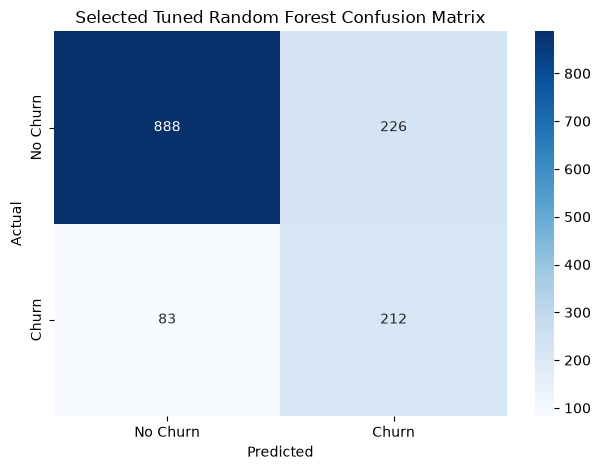

In [26]:
baseline_metrics = {
    "Accuracy": accuracy_score(y_test, rf_predictions),
    "Precision": precision_score(y_test, rf_predictions),
    "Recall": recall_score(y_test, rf_predictions),
    "F1 Score": f1_score(y_test, rf_predictions),
}
tuned_metrics = {
    "Accuracy": accuracy_score(y_test, rf_improved_predictions),
    "Precision": precision_score(y_test, rf_improved_predictions),
    "Recall": recall_score(y_test, rf_improved_predictions),
    "F1 Score": f1_score(y_test, rf_improved_predictions),
}
metrics_comparison = pd.DataFrame(
    [baseline_metrics, tuned_metrics],
    index=["Random Forest (baseline)", "Random Forest (tuned / selected)"]
)
print("Baseline vs selected model metrics:")
display(metrics_comparison.round(4))

selected_confusion_matrix = confusion_matrix(y_test, rf_improved_predictions)
sns.heatmap(selected_confusion_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
plt.title("Selected Tuned Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("images/viz5_confusion_matrix.png", dpi=160, bbox_inches="tight")
plt.show()

**Before:** default Random Forest. **After:** tuned Random Forest with class weighting and regularizing parameters.

The next cell computes both scores from the held-out test set, shows the full metric comparison, and plots the selected model's confusion matrix. This keeps the reported values tied to the executed run.

The tuning was chosen because the baseline recall on churners was low. Class weighting increases the cost of missing churners; limiting tree depth and requiring a minimum leaf size also helps control overfitting. We accept lower precision if recall improves, while tracking F1 to balance both.

### Challenge B — Risk Output


Thresholds of **0.70** and **0.40** are used to convert probability into HIGH / MEDIUM / LOW risk
(already wired into `predict_customer` above). These cut-points aren't universal — they were chosen so
that "HIGH" flags the customers the tuned model is genuinely confident about, and "MEDIUM" catches
borderline cases worth a lighter-touch nudge rather than a full retention campaign; a team could move
them once they know the retention budget available per risk tier.

In [27]:
print(predict_customer(sample_customer, model=rf_improved))

{'prediction': 'Customer likely to churn', 'churn_probability': np.float64(0.8795928521379275), 'risk_level': 'HIGH'}


### Feature Importance


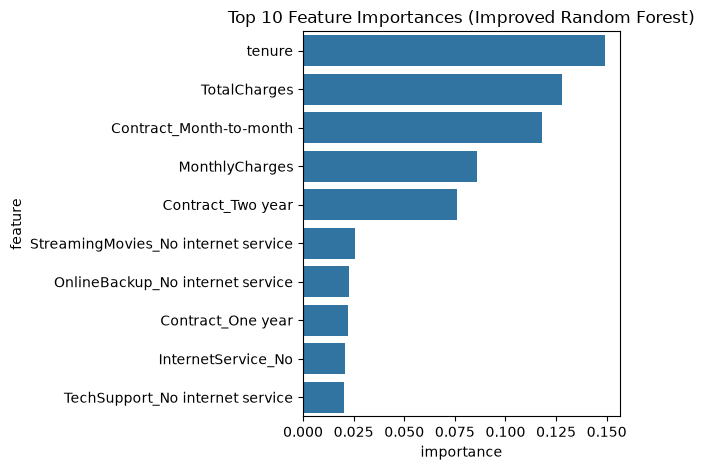

In [28]:
ohe = rf_improved.named_steps["preprocessor"].named_transformers_["categorical"]
ohe_names = ohe.get_feature_names_out(categorical_features).tolist()
all_feature_names = ohe_names + list(numeric_features)

importances = rf_improved.named_steps["model"].feature_importances_
feature_importance = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
}).sort_values("importance", ascending=False).head(10)

sns.barplot(data=feature_importance, y="feature", x="importance")
plt.title("Top 10 Feature Importances (Improved Random Forest)")
plt.tight_layout()
plt.savefig("images/viz6_feature_importance.png", dpi=160, bbox_inches="tight")
plt.show()

**Most influential features:** `tenure`, `TotalCharges`, `Contract_Month-to-month` — tenure, total spend so far and having a month-to-month contract dominate the model's decisions, which matches the patterns seen in the EDA charts above.

### Challenge C — Final Project Summary


In [29]:
joblib.dump(rf_improved, "churnguard_rf_model.joblib")
print("Model saved to churnguard_rf_model.joblib")

Model saved to churnguard_rf_model.joblib


In [30]:
import json
logistic_encoder = logistic_model.named_steps["preprocessor"].named_transformers_["categorical"]
logistic_categorical_names = logistic_encoder.get_feature_names_out(categorical_features).tolist()
demo_model_export = {
    "intercept": float(logistic_model.named_steps["model"].intercept_[0]),
    "coef_names": logistic_categorical_names + list(numeric_features),
    "coefs": logistic_model.named_steps["model"].coef_[0].tolist(),
    "categorical_features": list(categorical_features),
    "categories": {
        field: values.tolist()
        for field, values in zip(categorical_features, logistic_encoder.categories_)
    },
    "numeric_features": list(numeric_features),
}
print("DEMO_MODEL_JSON=" + json.dumps(demo_model_export, separators=(",", ":")))

DEMO_MODEL_JSON={"intercept":-0.5055384797466672,"coef_names":["gender_Female","gender_Male","Partner_No","Partner_Yes","Dependents_No","Dependents_Yes","PhoneService_No","PhoneService_Yes","MultipleLines_No","MultipleLines_No phone service","MultipleLines_Yes","InternetService_DSL","InternetService_Fiber optic","InternetService_No","OnlineSecurity_No","OnlineSecurity_No internet service","OnlineSecurity_Yes","OnlineBackup_No","OnlineBackup_No internet service","OnlineBackup_Yes","DeviceProtection_No","DeviceProtection_No internet service","DeviceProtection_Yes","TechSupport_No","TechSupport_No internet service","TechSupport_Yes","StreamingTV_No","StreamingTV_No internet service","StreamingTV_Yes","StreamingMovies_No","StreamingMovies_No internet service","StreamingMovies_Yes","Contract_Month-to-month","Contract_One year","Contract_Two year","PaperlessBilling_No","PaperlessBilling_Yes","PaymentMethod_Bank transfer (automatic)","PaymentMethod_Credit card (automatic)","PaymentMethod_Elec

In [31]:
from IPython.display import Markdown, display
selected_model_name = "Random Forest (tuned / improved)"
top_findings = feature_importance.head(3)["feature"].tolist()
summary = f"""## CHURNGUARD AI — FINAL RESULTS

**Dataset:** Synthetic Telco-style customer churn dataset (`dataset/customer_churn.csv`); {df.shape[1]} columns after cleaning.

**Number of records:** {raw_record_count:,} raw → {clean_record_count:,} after duplicate removal.

**Models tested:** Logistic Regression, Random Forest (baseline), Random Forest (tuned / improved).

**Selected model:** {selected_model_name}, with `class_weight=balanced`, `max_depth=10`, `min_samples_leaf=3`, and 400 trees.

| Metric | Selected model |
|---|---:|
| Accuracy | {tuned_metrics['Accuracy']:.4f} |
| Precision | {tuned_metrics['Precision']:.4f} |
| Recall | {tuned_metrics['Recall']:.4f} |
| F1 score | {tuned_metrics['F1 Score']:.4f} |

**Most important findings:**
1. `{top_findings[0]}` is the leading predictor; churn is concentrated among shorter-tenure customers.
2. `{top_findings[1]}` captures customer tenure and spend patterns associated with churn.
3. `{top_findings[2]}` highlights elevated churn among month-to-month customers.

**Business recommendation:** Prioritize early retention outreach for new, month-to-month customers flagged at higher risk. Test offers such as contract reviews, support follow-ups, or relevant service trials, and monitor both saved customers and offer cost.

**Limitations:** This dataset is synthetic and shaped like the IBM Telco data; results may not transfer to real customers. Probabilities are not guarantees, and lower precision means some customers flagged for outreach would stay without intervention. Validate on representative, current company data before using predictions for operational decisions."""
display(Markdown(summary))


## CHURNGUARD AI — FINAL RESULTS

**Dataset:** Synthetic Telco-style customer churn dataset (`dataset/customer_churn.csv`); 20 columns after cleaning.

**Number of records:** 7,058 raw → 7,043 after duplicate removal.

**Models tested:** Logistic Regression, Random Forest (baseline), Random Forest (tuned / improved).

**Selected model:** Random Forest (tuned / improved), with `class_weight=balanced`, `max_depth=10`, `min_samples_leaf=3`, and 400 trees.

| Metric | Selected model |
|---|---:|
| Accuracy | 0.7807 |
| Precision | 0.4840 |
| Recall | 0.7186 |
| F1 score | 0.5784 |

**Most important findings:**
1. `tenure` is the leading predictor; churn is concentrated among shorter-tenure customers.
2. `TotalCharges` captures customer tenure and spend patterns associated with churn.
3. `Contract_Month-to-month` highlights elevated churn among month-to-month customers.

**Business recommendation:** Prioritize early retention outreach for new, month-to-month customers flagged at higher risk. Test offers such as contract reviews, support follow-ups, or relevant service trials, and monitor both saved customers and offer cost.

**Limitations:** This dataset is synthetic and shaped like the IBM Telco data; results may not transfer to real customers. Probabilities are not guarantees, and lower precision means some customers flagged for outreach would stay without intervention. Validate on representative, current company data before using predictions for operational decisions.